# Stage 3: Positional Encoding

## The Problem: Attention is Position-Blind

Self-attention treats input as a **set**, not a **sequence**. Without position info:

```
"The cat sat on the mat"  →  Same attention as  →  "mat the on sat cat The"
```

This is a disaster for language! Word order matters.

### The Solution: Add Position Information

We'll explore 4 approaches used in modern transformers:

| Method | Used In | Key Idea |
|--------|---------|----------|
| **Sinusoidal** | Original Transformer | Fixed mathematical patterns |
| **Learned** | BERT, GPT-2 | Let the model learn positions |
| **RoPE** | LLaMA, Mistral | Rotate embeddings based on position |
| **ALiBi** | BLOOM, MPT | Bias attention scores by distance |

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

---
## 1. Sinusoidal Positional Encoding (Original Transformer)

The original "Attention Is All You Need" paper used **sine and cosine functions** at different frequencies.

### The Formula

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where:
- `pos` = position in the sequence (0, 1, 2, ...)
- `i` = dimension index (0, 1, 2, ... d_model/2)
- `d_model` = embedding dimension

### Why Sine/Cosine?

1. **Unique encoding** for each position
2. **Bounded values** (always between -1 and 1)
3. **Relative positions** can be expressed as linear transformations
4. **Generalizes** to longer sequences than seen in training

In [6]:
class SinusoidalPositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding from "Attention Is All You Need"
    
    Creates a fixed (non-learnable) encoding based on sine/cosine waves
    at different frequencies for each dimension.
    """
    
    def __init__(self, d_model, max_seq_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        # Create positional encoding matrix
        pe = torch.zeros(max_seq_len, d_model)
        
        # Position indices: [0, 1, 2, ..., max_seq_len-1]
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()
        
        # Dimension indices for the sin/cos: creates the 10000^(2i/d_model) term
        # Using exp and log for numerical stability
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        
        # Apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)  # Even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd dimensions
        
        # Add batch dimension: (max_seq_len, d_model) → (1, max_seq_len, d_model)
        pe = pe.unsqueeze(0)
        
        # Register as buffer (not a parameter, but saved with model)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        """
        Args:
            x: Input embeddings (batch, seq_len, d_model)
        Returns:
            x + positional encoding
        """
        # Add positional encoding (broadcasts across batch)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [7]:
# Test sinusoidal encoding
d_model = 128
max_seq_len = 100

pos_encoder = SinusoidalPositionalEncoding(d_model, max_seq_len, dropout=0.0)

# Create dummy input (zeros to see pure positional encoding)
x = torch.zeros(1, 50, d_model)
encoded = pos_encoder(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {encoded.shape}")
print(f"\nPositional encoding for position 0 (first 10 dims):")
print(encoded[0, 0, :10])
print(f"\nPositional encoding for position 1 (first 10 dims):")
print(encoded[0, 1, :10])

Input shape: torch.Size([1, 50, 128])
Output shape: torch.Size([1, 50, 128])

Positional encoding for position 0 (first 10 dims):
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])

Positional encoding for position 1 (first 10 dims):
tensor([0.8415, 0.5403, 0.7617, 0.6479, 0.6816, 0.7318, 0.6047, 0.7965, 0.5332,
        0.8460])


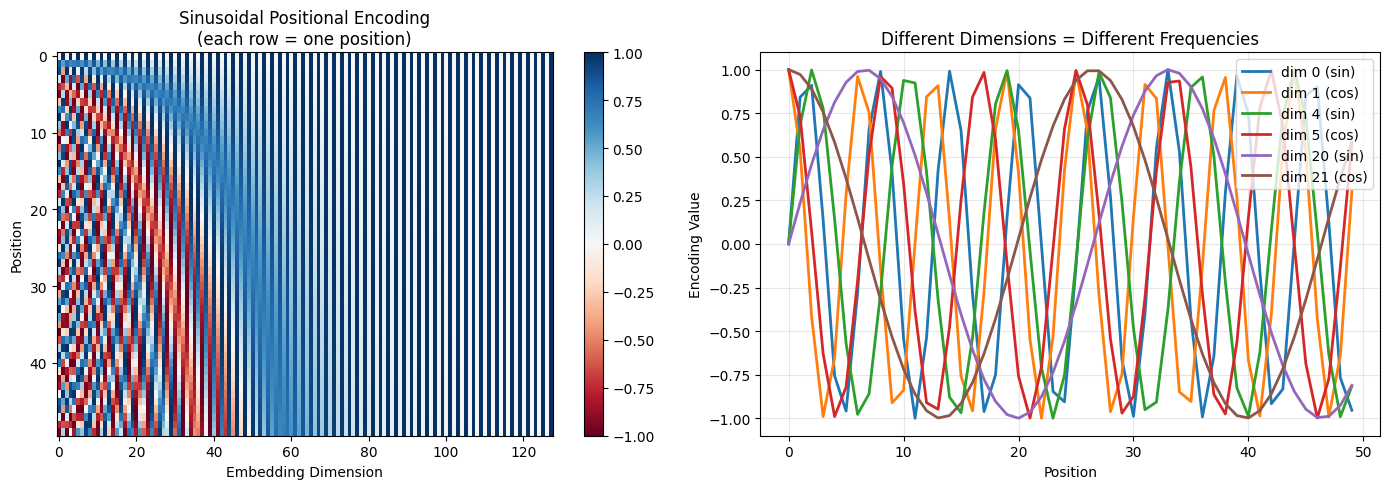

In [8]:
# Visualize the sinusoidal patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full positional encoding matrix
pe_matrix = pos_encoder.pe[0, :50, :].numpy()

ax1 = axes[0]
im1 = ax1.imshow(pe_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
ax1.set_xlabel('Embedding Dimension')
ax1.set_ylabel('Position')
ax1.set_title('Sinusoidal Positional Encoding\n(each row = one position)')
plt.colorbar(im1, ax=ax1)

# Show individual dimensions as waves
ax2 = axes[1]
positions = range(50)
for dim in [0, 1, 4, 5, 20, 21]:
    label = f'dim {dim} ({"sin" if dim % 2 == 0 else "cos"})'
    ax2.plot(positions, pe_matrix[:, dim], label=label, linewidth=2)
ax2.set_xlabel('Position')
ax2.set_ylabel('Encoding Value')
ax2.set_title('Different Dimensions = Different Frequencies')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Understanding the Visualization

- **Lower dimensions** (0, 1): High frequency waves - change rapidly with position
- **Higher dimensions** (20, 21): Low frequency waves - change slowly

This creates a **unique fingerprint** for each position!

```
Position 0:  [sin(0), cos(0), sin(0), cos(0), ...] = [0, 1, 0, 1, ...]
Position 1:  [sin(1/f), cos(1/f), sin(1/f'), cos(1/f'), ...]
Position 2:  [sin(2/f), cos(2/f), sin(2/f'), cos(2/f'), ...]
...
```

---
## 2. Learned Positional Encoding (BERT, GPT-2)

Why use fixed math when the model can **learn** the best position representations?

### The Idea

Simply create an embedding table for positions (just like word embeddings):

```
Position 0 → Look up embedding[0] → [0.2, -0.1, 0.5, ...]
Position 1 → Look up embedding[1] → [0.3, 0.4, -0.2, ...]
...
```

In [9]:
class LearnedPositionalEncoding(nn.Module):
    """
    Learned Positional Encoding (like BERT, GPT-2)
    
    Each position has a learnable embedding vector.
    Simple but effective! The downside: can't generalize beyond max_seq_len.
    """
    
    def __init__(self, d_model, max_seq_len=512, dropout=0.1):
        super().__init__()
        
        # Learnable position embeddings
        self.position_embeddings = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Register position indices as buffer
        self.register_buffer(
            'position_ids',
            torch.arange(max_seq_len).unsqueeze(0)  # (1, max_seq_len)
        )
        
    def forward(self, x):
        """
        Args:
            x: Input embeddings (batch, seq_len, d_model)
        Returns:
            x + positional encoding
        """
        seq_len = x.size(1)
        
        # Get position IDs for this sequence length
        position_ids = self.position_ids[:, :seq_len]
        
        # Look up position embeddings
        position_embeddings = self.position_embeddings(position_ids)
        
        # Add to input
        x = x + position_embeddings
        return self.dropout(x)

In [10]:
# Test learned encoding
d_model = 128
max_seq_len = 100

learned_encoder = LearnedPositionalEncoding(d_model, max_seq_len, dropout=0.0)

# Check parameters (these are learnable!)
print(f"Learnable parameters: {sum(p.numel() for p in learned_encoder.parameters()):,}")
print(f"→ {max_seq_len} positions × {d_model} dimensions = {max_seq_len * d_model:,}")

# Test forward pass
x = torch.zeros(1, 50, d_model)
encoded = learned_encoder(x)
print(f"\nOutput shape: {encoded.shape}")

Learnable parameters: 12,800
→ 100 positions × 128 dimensions = 12,800

Output shape: torch.Size([1, 50, 128])


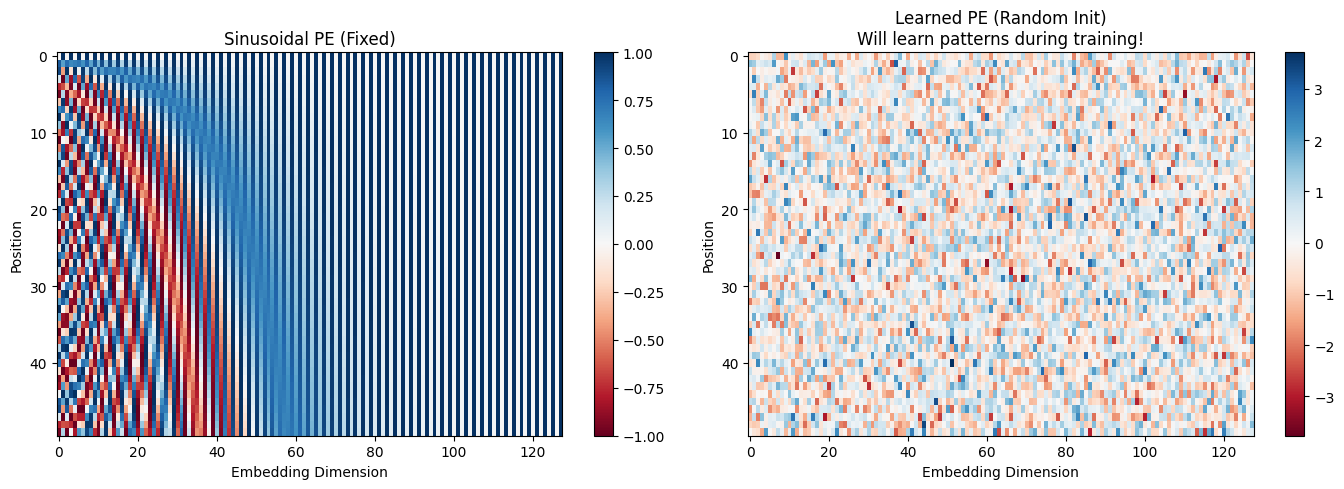

In [11]:
# Visualize learned vs sinusoidal (random init for learned)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sinusoidal
ax1 = axes[0]
sin_pe = pos_encoder.pe[0, :50, :].numpy()
im1 = ax1.imshow(sin_pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
ax1.set_xlabel('Embedding Dimension')
ax1.set_ylabel('Position')
ax1.set_title('Sinusoidal PE (Fixed)')
plt.colorbar(im1, ax=ax1)

# Learned (random initialization)
ax2 = axes[1]
learned_pe = learned_encoder.position_embeddings.weight[:50, :].detach().numpy()
im2 = ax2.imshow(learned_pe, cmap='RdBu', aspect='auto')
ax2.set_xlabel('Embedding Dimension')
ax2.set_ylabel('Position')
ax2.set_title('Learned PE (Random Init)\nWill learn patterns during training!')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

### Sinusoidal vs Learned: Trade-offs

| Aspect | Sinusoidal | Learned |
|--------|------------|--------|
| Parameters | 0 (fixed) | seq_len × d_model |
| Extrapolation | ✅ Can handle unseen lengths | ❌ Limited to max_seq_len |
| Flexibility | ❌ Fixed pattern | ✅ Can learn task-specific patterns |
| Performance | Good | Often slightly better |

**In practice**: BERT, GPT-2 used learned. Modern LLMs (LLaMA, Mistral) use RoPE.

---
## 3. Rotary Positional Encoding (RoPE)

**RoPE** is used in most modern LLMs (LLaMA, Mistral, Qwen, etc.). It's elegant!

### The Key Insight

Instead of **adding** position to embeddings, we **rotate** them in 2D subspaces:

```
Sinusoidal/Learned:    x' = x + PE(position)
RoPE:                  x' = Rotate(x, position)
```

### Why Rotation?

The dot product between two rotated vectors depends on their **relative rotation**:

$$q_m \cdot k_n = Rotate(q, m) \cdot Rotate(k, n) = f(q, k, m-n)$$

This means the attention between positions m and n naturally captures their **relative distance** (m-n)!

### The Formula

For a 2D rotation by angle θ:
$$\begin{pmatrix} x' \\ y' \end{pmatrix} = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix}$$

RoPE applies this to pairs of dimensions, with position-dependent angles.

In [12]:
class RotaryPositionalEncoding(nn.Module):
    """
    Rotary Positional Encoding (RoPE) - Used in LLaMA, Mistral, etc.
    
    Instead of adding position info, we ROTATE the query and key vectors.
    This naturally encodes relative positions in the attention scores.
    """
    
    def __init__(self, d_model, max_seq_len=4096, base=10000):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        self.base = base
        
        # Compute the rotation frequencies for each dimension pair
        # θ_i = 10000^(-2i/d) for i in [0, 1, ..., d/2-1]
        inv_freq = 1.0 / (base ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer('inv_freq', inv_freq)
        
        # Precompute sin/cos for all positions
        self._build_cache(max_seq_len)
        
    def _build_cache(self, seq_len):
        """Precompute sin and cos values for efficiency."""
        # Position indices
        t = torch.arange(seq_len, device=self.inv_freq.device).float()
        
        # Outer product: positions × frequencies → angles
        # Shape: (seq_len, d_model/2)
        freqs = torch.outer(t, self.inv_freq)
        
        # Duplicate for both sin and cos application
        # Shape: (seq_len, d_model)
        emb = torch.cat([freqs, freqs], dim=-1)
        
        self.register_buffer('cos_cached', emb.cos())
        self.register_buffer('sin_cached', emb.sin())
    
    def forward(self, x, seq_len=None):
        """
        Apply rotary embeddings to input.
        
        Args:
            x: (batch, seq_len, d_model) or (batch, heads, seq_len, d_k)
            seq_len: actual sequence length (if different from x.size)
        """
        if seq_len is None:
            seq_len = x.size(-2)
            
        cos = self.cos_cached[:seq_len]
        sin = self.sin_cached[:seq_len]
        
        return self._apply_rotary(x, cos, sin)
    
    def _apply_rotary(self, x, cos, sin):
        """
        Apply the rotation.
        
        The trick: instead of matrix multiplication, we use:
        x_rotated = x * cos + rotate_half(x) * sin
        
        Where rotate_half swaps and negates pairs: [x1, x2, x3, x4] → [-x2, x1, -x4, x3]
        """
        # Reshape for broadcasting
        # x: (..., seq_len, d_model)
        # cos, sin: (seq_len, d_model)
        
        # Create the rotated version
        x_rotated = self._rotate_half(x)
        
        # Apply rotation: x' = x * cos(θ) + x_rotated * sin(θ)
        return x * cos + x_rotated * sin
    
    def _rotate_half(self, x):
        """
        Rotate pairs of dimensions.
        [x0, x1, x2, x3, ...] → [-x1, x0, -x3, x2, ...]
        
        This is equivalent to rotating each 2D pair by 90 degrees.
        """
        x1 = x[..., :x.size(-1)//2]  # First half
        x2 = x[..., x.size(-1)//2:]  # Second half
        return torch.cat([-x2, x1], dim=-1)

In [13]:
# Test RoPE
d_model = 64
seq_len = 10

rope = RotaryPositionalEncoding(d_model)

# Create a query vector
q = torch.randn(1, seq_len, d_model)

# Apply RoPE
q_rotated = rope(q)

print(f"Original Q shape: {q.shape}")
print(f"Rotated Q shape:  {q_rotated.shape}")

# The vectors have the same norm (rotation preserves length!)
print(f"\nOriginal norm (pos 0): {q[0, 0].norm():.4f}")
print(f"Rotated norm (pos 0):  {q_rotated[0, 0].norm():.4f}")

Original Q shape: torch.Size([1, 10, 64])
Rotated Q shape:  torch.Size([1, 10, 64])

Original norm (pos 0): 8.2651
Rotated norm (pos 0):  8.2651


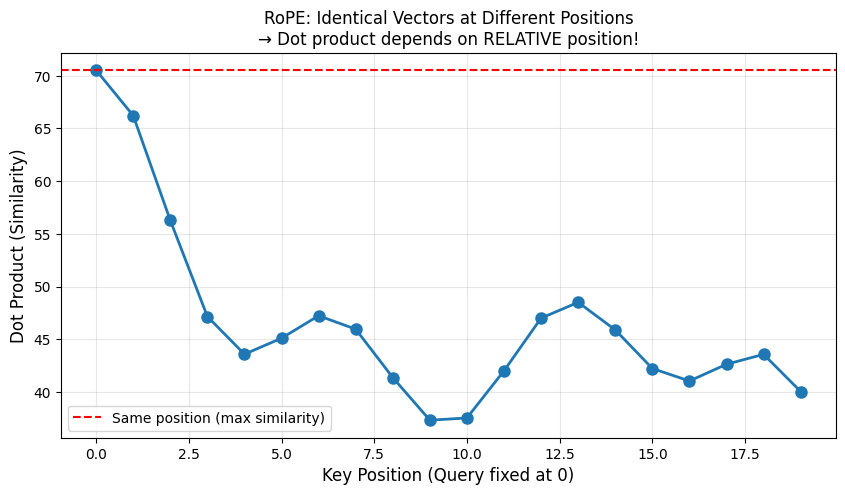

Key insight: Same vectors at same position → max similarity
As distance increases → similarity decreases (with wavelike pattern)


In [14]:
# Visualize: How RoPE creates relative position awareness

d_model = 64
rope = RotaryPositionalEncoding(d_model)

# Create identical query and key vectors
torch.manual_seed(42)
q = torch.randn(1, 1, d_model)  # Single query
k = q.clone()                    # Identical key

# Place them at different positions and compute dot product
positions = range(20)
dot_products = []

# Fix query at position 0
q_at_0 = rope._apply_rotary(
    q, 
    rope.cos_cached[0:1],
    rope.sin_cached[0:1]
)

for pos in positions:
    # Key at different positions
    k_at_pos = rope._apply_rotary(
        k,
        rope.cos_cached[pos:pos+1],
        rope.sin_cached[pos:pos+1]
    )
    
    # Dot product
    dot = (q_at_0 * k_at_pos).sum().item()
    dot_products.append(dot)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(positions, dot_products, 'o-', linewidth=2, markersize=8)
plt.axhline(y=dot_products[0], color='r', linestyle='--', label='Same position (max similarity)')
plt.xlabel('Key Position (Query fixed at 0)', fontsize=12)
plt.ylabel('Dot Product (Similarity)', fontsize=12)
plt.title('RoPE: Identical Vectors at Different Positions\n→ Dot product depends on RELATIVE position!', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Key insight: Same vectors at same position → max similarity")
print("As distance increases → similarity decreases (with wavelike pattern)")

### RoPE in Multi-Head Attention

RoPE is applied to Q and K **after** projection, **before** attention:

```python
Q = W_Q(x)                    # Project
K = W_K(x)
V = W_V(x)

Q = apply_rope(Q, positions)  # Apply RoPE to Q and K only!
K = apply_rope(K, positions)  # V is NOT rotated

attention = softmax(Q @ K^T / sqrt(d_k)) @ V
```

In [15]:
class MultiHeadAttentionWithRoPE(nn.Module):
    """
    Multi-Head Attention with Rotary Positional Encoding.
    This is how modern LLMs (LLaMA, Mistral) implement attention.
    """
    
    def __init__(self, d_model, num_heads, max_seq_len=4096, dropout=0.1):
        super().__init__()
        
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        # RoPE for positional encoding (per-head dimension)
        self.rope = RotaryPositionalEncoding(self.d_k, max_seq_len)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        
        # Project to Q, K, V
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # Apply RoPE to Q and K (NOT V!)
        Q = self.rope(Q)
        K = self.rope(K)
        
        # Standard attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        output = torch.matmul(attn_weights, V)
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        return self.W_O(output), attn_weights

# Test
mha_rope = MultiHeadAttentionWithRoPE(d_model=256, num_heads=8)
x = torch.randn(2, 100, 256)
output, attn = mha_rope(x)
print(f"Output shape: {output.shape}")
print(f"Attention shape: {attn.shape}")

Output shape: torch.Size([2, 100, 256])
Attention shape: torch.Size([2, 8, 100, 100])


---
## 4. ALiBi (Attention with Linear Biases)

**ALiBi** takes a completely different approach: don't modify embeddings at all!

### The Idea

Instead of adding position to embeddings, **subtract a penalty** from attention scores based on distance:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} - m \cdot |i-j|\right) V$$

Where:
- `|i-j|` = distance between positions
- `m` = head-specific slope (different for each head)

### Why It Works

- Tokens far apart get **penalized** → attend less to distant tokens
- Different heads have different slopes → some focus locally, others globally
- **Zero extra parameters!** Just a bias term

In [16]:
class ALiBiPositionalEncoding(nn.Module):
    """
    ALiBi: Attention with Linear Biases
    
    No learned parameters! Just penalize attention based on distance.
    Used in BLOOM, MPT, and others.
    """
    
    def __init__(self, num_heads):
        super().__init__()
        self.num_heads = num_heads
        
        # Compute slopes for each head
        # Slopes are: 2^(-8/n), 2^(-16/n), 2^(-24/n), ...
        # This gives a geometric sequence
        slopes = self._get_slopes(num_heads)
        self.register_buffer('slopes', slopes)
        
    def _get_slopes(self, num_heads):
        """
        Get the slope for each head.
        Heads have different slopes to capture different ranges of context.
        """
        def get_slopes_power_of_2(n):
            start = 2 ** (-(2 ** -(math.log2(n) - 3)))
            ratio = start
            return [start * (ratio ** i) for i in range(n)]
        
        if math.log2(num_heads).is_integer():
            return torch.tensor(get_slopes_power_of_2(num_heads))
        else:
            # Handle non-power-of-2 heads
            closest_power = 2 ** math.floor(math.log2(num_heads))
            slopes = get_slopes_power_of_2(closest_power)
            extra = get_slopes_power_of_2(2 * closest_power)[0::2][:num_heads - closest_power]
            return torch.tensor(slopes + extra)
    
    def forward(self, seq_len):
        """
        Create ALiBi bias matrix.
        
        Returns:
            bias: (num_heads, seq_len, seq_len) - to be ADDED to attention scores
        """
        # Create distance matrix: |i - j|
        # Position indices
        positions = torch.arange(seq_len, device=self.slopes.device)
        
        # Distance matrix (i - j for all pairs)
        # For causal attention, we only care about i >= j, so distances are non-negative
        distance = positions.unsqueeze(0) - positions.unsqueeze(1)  # (seq_len, seq_len)
        
        # For causal: use negative distances (penalty)
        # Multiply by slopes (different for each head)
        # slopes: (num_heads,) → (num_heads, 1, 1)
        bias = -distance.unsqueeze(0) * self.slopes.unsqueeze(1).unsqueeze(2)
        
        return bias  # (num_heads, seq_len, seq_len)

ALiBi slopes per head: [0.5        0.25       0.125      0.0625     0.03125    0.015625
 0.0078125  0.00390625]
Bias shape: torch.Size([8, 20, 20])


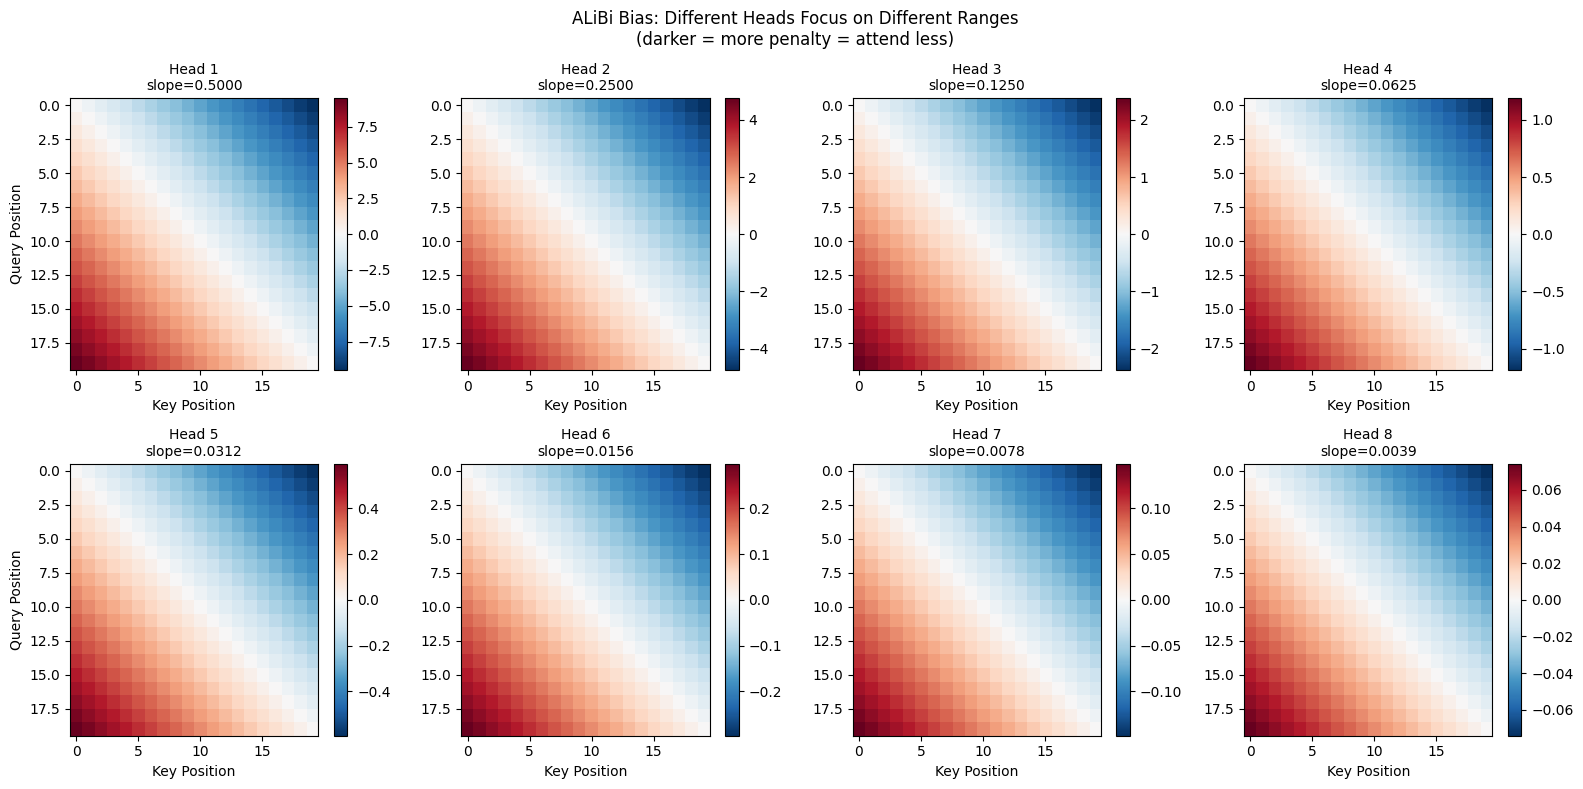

In [17]:
# Visualize ALiBi biases
num_heads = 8
seq_len = 20

alibi = ALiBiPositionalEncoding(num_heads)
bias = alibi(seq_len)

print(f"ALiBi slopes per head: {alibi.slopes.numpy()}")
print(f"Bias shape: {bias.shape}")

# Visualize for different heads
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head_idx in range(num_heads):
    ax = axes[head_idx]
    im = ax.imshow(bias[head_idx].numpy(), cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Head {head_idx+1}\nslope={alibi.slopes[head_idx]:.4f}', fontsize=10)
    ax.set_xlabel('Key Position')
    if head_idx % 4 == 0:
        ax.set_ylabel('Query Position')
    plt.colorbar(im, ax=ax)

plt.suptitle('ALiBi Bias: Different Heads Focus on Different Ranges\n(darker = more penalty = attend less)', fontsize=12)
plt.tight_layout()
plt.show()

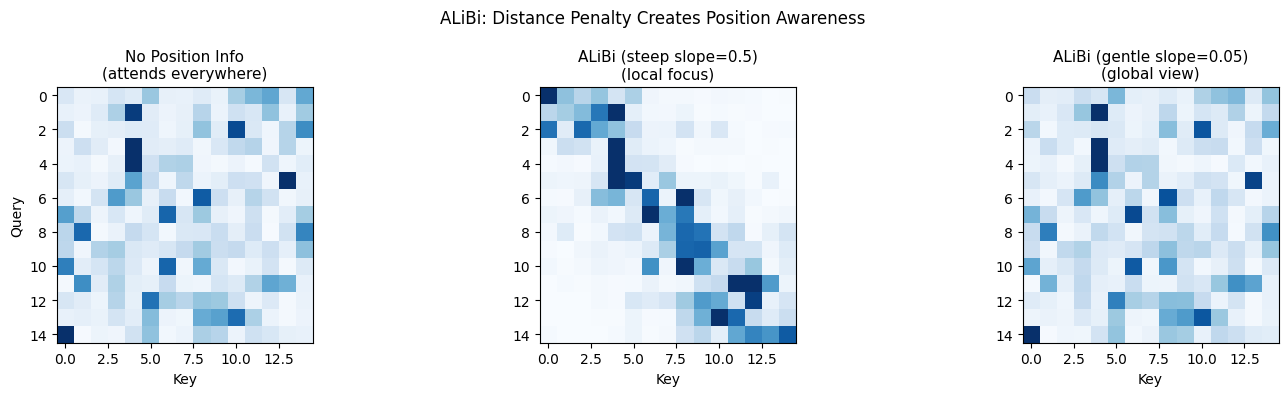

In [18]:
# Show how ALiBi affects attention patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

seq_len = 15
d_k = 64

# Random Q, K
torch.manual_seed(42)
Q = torch.randn(1, 1, seq_len, d_k)  # Single head
K = torch.randn(1, 1, seq_len, d_k)

# Raw attention scores (no position info)
raw_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
raw_attn = F.softmax(raw_scores, dim=-1)

# With ALiBi (steep slope - local focus)
alibi_bias_steep = -0.5 * torch.abs(torch.arange(seq_len).unsqueeze(0) - torch.arange(seq_len).unsqueeze(1))
alibi_scores_steep = raw_scores + alibi_bias_steep.unsqueeze(0).unsqueeze(0)
alibi_attn_steep = F.softmax(alibi_scores_steep, dim=-1)

# With ALiBi (gentle slope - global view)
alibi_bias_gentle = -0.05 * torch.abs(torch.arange(seq_len).unsqueeze(0) - torch.arange(seq_len).unsqueeze(1))
alibi_scores_gentle = raw_scores + alibi_bias_gentle.unsqueeze(0).unsqueeze(0)
alibi_attn_gentle = F.softmax(alibi_scores_gentle, dim=-1)

# Plot
axes[0].imshow(raw_attn[0, 0].numpy(), cmap='Blues', vmin=0, vmax=0.3)
axes[0].set_title('No Position Info\n(attends everywhere)', fontsize=11)
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Query')

axes[1].imshow(alibi_attn_steep[0, 0].numpy(), cmap='Blues', vmin=0, vmax=0.3)
axes[1].set_title('ALiBi (steep slope=0.5)\n(local focus)', fontsize=11)
axes[1].set_xlabel('Key')

axes[2].imshow(alibi_attn_gentle[0, 0].numpy(), cmap='Blues', vmin=0, vmax=0.3)
axes[2].set_title('ALiBi (gentle slope=0.05)\n(global view)', fontsize=11)
axes[2].set_xlabel('Key')

plt.suptitle('ALiBi: Distance Penalty Creates Position Awareness', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Comparison: All Methods Together

In [ ]:
# Summary comparison
comparison = """
┌─────────────────────────────────────────────────────────────────────────────────┐
│                    POSITIONAL ENCODING METHODS COMPARISON                       │
├──────────────┬──────────────┬──────────────┬──────────────┬────────────────────┤
│    Method    │  Parameters  │ Extrapolates │  Where Added │     Used In        │
├──────────────┼──────────────┼──────────────┼──────────────┼────────────────────┤
│  Sinusoidal  │     0        │      ✅      │  Embeddings  │ Original Transformer│
├──────────────┼──────────────┼──────────────┼──────────────┼────────────────────┤
│   Learned    │  seq × d     │      ❌      │  Embeddings  │ BERT, GPT-2        │
├──────────────┼──────────────┼──────────────┼──────────────┼────────────────────┤
│    RoPE      │     0        │      ✅      │    Q, K      │ LLaMA, Mistral     │
├──────────────┼──────────────┼──────────────┼──────────────┼────────────────────┤
│   ALiBi      │     0        │      ✅      │  Attn Scores │ BLOOM, MPT         │
└──────────────┴──────────────┴──────────────┴──────────────┴────────────────────┘
"""
print(comparison)

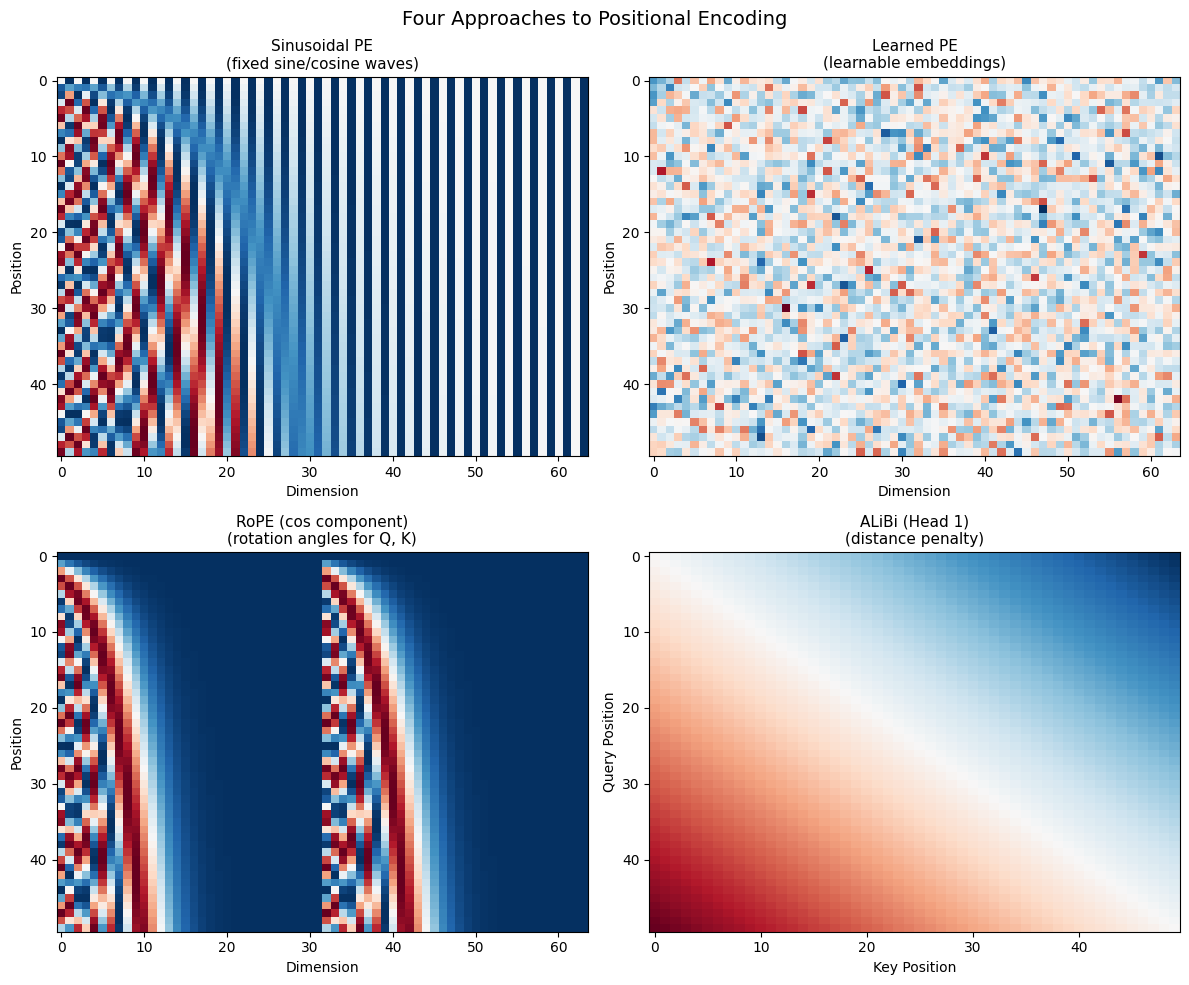

In [19]:
# Visualize all methods side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

d_model = 64
seq_len = 50

# 1. Sinusoidal
sin_pe = SinusoidalPositionalEncoding(d_model, seq_len, dropout=0.0)
sin_matrix = sin_pe.pe[0, :seq_len, :].numpy()
axes[0, 0].imshow(sin_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0, 0].set_title('Sinusoidal PE\n(fixed sine/cosine waves)', fontsize=11)
axes[0, 0].set_xlabel('Dimension')
axes[0, 0].set_ylabel('Position')

# 2. Learned (random init)
torch.manual_seed(42)
learned_pe = LearnedPositionalEncoding(d_model, seq_len, dropout=0.0)
learned_matrix = learned_pe.position_embeddings.weight[:seq_len, :].detach().numpy()
axes[0, 1].imshow(learned_matrix, cmap='RdBu', aspect='auto')
axes[0, 1].set_title('Learned PE\n(learnable embeddings)', fontsize=11)
axes[0, 1].set_xlabel('Dimension')
axes[0, 1].set_ylabel('Position')

# 3. RoPE - show rotation angles
rope = RotaryPositionalEncoding(d_model, seq_len)
# Show the cos values (rotation matrix diagonal)
rope_matrix = rope.cos_cached[:seq_len, :].numpy()
axes[1, 0].imshow(rope_matrix, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[1, 0].set_title('RoPE (cos component)\n(rotation angles for Q, K)', fontsize=11)
axes[1, 0].set_xlabel('Dimension')
axes[1, 0].set_ylabel('Position')

# 4. ALiBi - show bias matrix for one head
alibi = ALiBiPositionalEncoding(num_heads=8)
alibi_matrix = alibi(seq_len)[0].numpy()  # First head
axes[1, 1].imshow(alibi_matrix, cmap='RdBu_r', aspect='auto')
axes[1, 1].set_title('ALiBi (Head 1)\n(distance penalty)', fontsize=11)
axes[1, 1].set_xlabel('Key Position')
axes[1, 1].set_ylabel('Query Position')

plt.suptitle('Four Approaches to Positional Encoding', fontsize=14)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Position Similarity

For sinusoidal encoding, compute the dot product between position encodings at different distances. What pattern do you see?

In [ ]:
# TODO: Compute dot product between PE(0) and PE(i) for i in range(50)
# Plot the results
# What does this tell us about relative position encoding?

def position_similarity(pe_module, max_dist=50):
    """
    Compute similarity between position 0 and all other positions.
    """
    # Your implementation here
    pass

### Exercise 2: Implement RoPE for Variable Positions

Modify RoPE to handle non-contiguous position IDs (useful for KV cache).

In [ ]:
# TODO: Modify RoPE to accept a position_ids tensor
# Example: position_ids = [0, 1, 5, 6, 7] (skipping 2, 3, 4)

def apply_rope_with_positions(x, position_ids, cos_cached, sin_cached):
    """
    Apply RoPE to x at specific positions (not necessarily contiguous).
    """
    # Your implementation here
    pass

### Exercise 3: ALiBi with Different Slope Schedules

Experiment with different slope schedules for ALiBi. How does it affect the attention patterns?

In [ ]:
# TODO: Implement ALiBi with linear slopes instead of geometric
# Compare attention patterns

def linear_alibi_slopes(num_heads):
    """
    Create linearly spaced slopes instead of geometric.
    """
    # Your implementation here
    pass

---
## Summary

### What We Learned

1. **The Problem**: Self-attention has no position awareness

2. **Four Solutions**:
   - **Sinusoidal**: Fixed mathematically, extrapolates well
   - **Learned**: Flexible, limited to training length
   - **RoPE**: Rotates Q/K, encodes relative position, modern standard
   - **ALiBi**: Biases scores, zero parameters, excellent extrapolation

3. **Key Insight**: RoPE and ALiBi are **relative** position methods, while Sinusoidal and Learned are **absolute**

### When to Use What?

| Situation | Recommendation |
|-----------|----------------|
| Modern LLM from scratch | **RoPE** (most popular) |
| Need long context extrapolation | **ALiBi** or **RoPE with NTK scaling** |
| Fine-tuning BERT-like model | **Learned** (match pretrained) |
| Educational/understanding | **Sinusoidal** (elegant math) |

### Next Up: Layer Normalization & Feed-Forward Networks

We've covered attention and positions. Now we need:
- **Layer Normalization**: Training stability
- **Feed-Forward Networks**: Where most parameters live!